# Au [100] KG ODE convergence study

This notebook validates the numerical reference produced by `simulate_kg_ode_full` for the 300 keV Au [100] plane-wave benchmark. It checks three independent approximations:

1. **Longitudinal sampling:** convergence with the number of potential slices per unit cell.
2. **Transverse sampling:** convergence with the lateral Fourier-grid size at fixed physical field of view.
3. **Unit-cell chaining:** equivalence between carrying both $\psi$ and $\partial_z\psi$ through repeated unit-cell calls and integrating the concatenated potential in one call.

All comparisons use 25 Au unit cells ($\approx 10.19$ nm) and the Weickenmeier--Kohl potential. Expensive studies are disabled by default. Enable them independently in the configuration cell; completed results and in-progress per-cell checkpoints are saved under `notebooks/verification/results/` and loaded on later runs.

The convergence criterion used here is a relative error below $10^{-3}$ (0.1%).


In [1]:
import gc
import json
import os
import sys
from pathlib import Path
from time import perf_counter

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", ".7")

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from abtem.parametrizations import Parametrization
from ase.build import bulk
from IPython.display import Markdown, display
from scipy.special import erfc as scipy_erfc
from tqdm.auto import tqdm


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "wide_angle_propagation").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the WideAnglePropagation repository root.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    simulate_kg_ode_full,
)

abtem.config.set({"device": "gpu", "precision": "float64"})
jax.config.update("jax_enable_x64", True)

RESULTS_DIR = REPO_ROOT / "notebooks" / "verification" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repository root: {REPO_ROOT}")
print(f"Results directory: {RESULTS_DIR}")

Repository root: /home/dl277493/Documents/Code/WideAnglePropagation
Results directory: /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/results


## Configuration

The run switches are independent. Leave a switch `False` to load compatible saved results without recomputing that study. Set `FORCE_RECOMPUTE = True` together with the relevant run switch only when deliberately replacing existing results.

The transverse comparison keeps the physical $4.076\times4.076$ Å unit-cell field of view fixed. Consequently, the reciprocal-grid spacing is identical and the common Fourier coefficients align exactly between resolutions. The default $256\times256$ transverse reference is a practical first pass; the preflight table also reports the cost of an optional final $384\times384$ confirmation.


In [2]:
# Expensive calculations are opt-in so that Run All does not launch them accidentally.
RUN_LONGITUDINAL = False
RUN_TRANSVERSE = True
RUN_CHAINING = False
LOAD_EXISTING_RESULTS = True
FORCE_RECOMPUTE = True

CONFIG_VERSION = 1
ENERGY_EV = 300e3
AU_LATTICE_A = 4.076
N_CELLS = 25
RTOL = 1e-9
ATOL = 1e-11
SOLVER_NAME = "dopri8"
CONVERGENCE_THRESHOLD = 1e-3

LONGITUDINAL_GPTS = 128
LONGITUDINAL_SLICES = (32, 64, 128, 256, 512)
LONGITUDINAL_REFERENCE_SLICES = 512

# The transverse sweep uses independently validated, still-tight solver tolerances.
# A one-cell 128x128x256 pilot differed from 1e-9/1e-11 by about 5e-7.
TRANSVERSE_RTOL = 1e-8
TRANSVERSE_ATOL = 1e-10
TRANSVERSE_SLICES = 256
TRANSVERSE_GPTS = (64, 96, 128, 192, 256)
TRANSVERSE_REFERENCE_GPTS = 256
TRANSVERSE_PREFLIGHT_GPTS = (64, 96, 128, 192, 256, 384)
# For an ultrafine final confirmation, add 384 to TRANSVERSE_GPTS and set
# TRANSVERSE_REFERENCE_GPTS = 384. Per-cell checkpoints make that run resumable.

CHAIN_GPTS = 128
CHAIN_SLICES = 128
CHAIN_LENGTHS = (1, 5, 10, 25)

CELL_THICKNESS_A = AU_LATTICE_A
THICKNESS_CELLS = np.arange(1, N_CELLS + 1, dtype=int)
THICKNESS_NM = THICKNESS_CELLS * CELL_THICKNESS_A / 10.0
WAVELENGTH_A = float(energy2wavelength(ENERGY_EV))

print(f"Au [100], energy = {ENERGY_EV / 1e3:.0f} keV, wavelength = {WAVELENGTH_A:.5f} Å")
print(f"Thickness = {N_CELLS} cells = {THICKNESS_NM[-1]:.3f} nm")
print(f"Default ODE tolerances: rtol={RTOL:.0e}, atol={ATOL:.0e}; acceptance threshold={CONVERGENCE_THRESHOLD:.0e}")
print(f"Transverse ODE tolerances: rtol={TRANSVERSE_RTOL:.0e}, atol={TRANSVERSE_ATOL:.0e}")


Au [100], energy = 300 keV, wavelength = 0.01969 Å
Thickness = 25 cells = 10.190 nm
Default ODE tolerances: rtol=1e-09, atol=1e-11; acceptance threshold=1e-03
Transverse ODE tolerances: rtol=1e-08, atol=1e-10


## Au potential and propagation helpers

Each resolution rebuilds the same periodic Au [100] unit cell with the Weickenmeier--Kohl parametrization. The projected potential returned by abTEM is divided by the slice thickness to recover the slice-averaged three-dimensional potential expected by the KG ODE solver.

The propagation helper always carries both the wavefunction and its longitudinal derivative between cells.

In [3]:
def weickenmeier_kohl_function(k2, parameters):
    A, B = parameters
    s2 = k2 / 4.0
    term = -np.expm1(-B * s2[..., None])
    summed = np.sum(A * term, axis=-1)
    with np.errstate(divide="ignore", invalid="ignore"):
        f_s = summed / s2
    f_s = np.where(s2 == 0, np.sum(A * B), f_s)
    return f_s * 47.87801


def weickenmeier_kohl_potential(r, parameters):
    A, B = parameters
    r = np.asarray(r, dtype=np.float64)
    result = np.zeros_like(r)
    for idx in range(len(A)):
        result += A[idx] * scipy_erfc(2 * np.pi * r / np.sqrt(B[idx]))
    with np.errstate(divide="ignore", invalid="ignore"):
        potential = 47.87801 * 4 * np.pi * result / r
    return np.where(r < 1e-14, 1e30, potential)


class WeickenmeierKohlParametrization(Parametrization):
    def __init__(self):
        super().__init__(parameters={})
        self._functions = {
            "elastic": weickenmeier_kohl_function,
            "projected_scattering_factor": weickenmeier_kohl_function,
            "potential": weickenmeier_kohl_potential,
        }

    def scaled_parameters(self, symbol, name):
        if "Au" not in symbol:
            raise NotImplementedError("Only Au is implemented in this convergence notebook.")
        Z = 79
        V = 0.4
        B = np.array([5.493e-01, 1.728e00, 6.720e00, 2.637e-02, 7.253e-02, 3.546e01])
        factor = 0.02395 * Z
        a1 = factor / (3 * (1 + V))
        A = np.array([a1, a1, a1, V * a1, V * a1, V * a1])
        return [A, B]

    def cutoff(self, symbol):
        return 20.0


AU_ATOMS = bulk("Au", "fcc", a=AU_LATTICE_A, cubic=True)
AU_ATOMS.info["thermal_sigma"] = 0.0
AU_ATOMS.arrays["thermal_sigma"] = np.zeros(len(AU_ATOMS))
WK_PARAMETRIZATION = WeickenmeierKohlParametrization()


def to_host(array):
    if isinstance(array, cupy.ndarray):
        return cupy.asnumpy(array)
    return np.asarray(array)


def release_memory():
    gc.collect()
    cupy.get_default_memory_pool().free_all_blocks()


def build_au_cell(gpts, slices_per_cell):
    gpts = int(gpts)
    slices_per_cell = int(slices_per_cell)
    dz = CELL_THICKNESS_A / slices_per_cell
    potential = abtem.Potential(
        AU_ATOMS,
        gpts=(gpts, gpts),
        slice_thickness=dz,
        projection="finite",
        parametrization=WK_PARAMETRIZATION,
    )
    sampling = tuple(float(value) for value in potential.sampling)
    array = to_host(potential.build(lazy=False).array).astype(np.float64, copy=False) / dz
    if array.shape != (slices_per_cell, gpts, gpts):
        raise RuntimeError(f"Unexpected potential shape {array.shape}; expected {(slices_per_cell, gpts, gpts)}")
    probe = np.ones((gpts, gpts), dtype=np.complex128)
    release_memory()
    return jnp.asarray(array), jnp.asarray(probe), sampling, dz


def propagate_repeated_cells(
    cell_potential,
    probe,
    dz,
    sampling,
    n_cells,
    record_cells=None,
    description="KG ODE",
    rtol=RTOL,
    atol=ATOL,
    checkpoint_path=None,
    checkpoint_config=None,
    record_phis=True,
):
    record_cells = set(range(1, n_cells + 1) if record_cells is None else record_cells)
    checkpoint_path = None if checkpoint_path is None else Path(checkpoint_path)
    checkpoint_config_json = canonical_json({} if checkpoint_config is None else checkpoint_config)

    wave = jnp.asarray(probe, dtype=jnp.complex128)
    phi = None
    cells, waves, phis, runtimes = [], [], [], []
    start_cell = 1

    if checkpoint_path is not None and LOAD_EXISTING_RESULTS and checkpoint_path.exists() and not FORCE_RECOMPUTE:
        with np.load(checkpoint_path, allow_pickle=False) as checkpoint:
            stored_config = str(checkpoint["config_json"].item())
            if stored_config == checkpoint_config_json:
                completed_cell = int(checkpoint["completed_cell"].item())
                wave = jnp.asarray(checkpoint["last_wave"])
                phi = jnp.asarray(checkpoint["last_phi"])
                cells = list(checkpoint["cells"].astype(int))
                waves = list(checkpoint["waves"])
                phis = list(checkpoint["phis"])
                runtimes = list(checkpoint["runtime_s"].astype(float))
                start_cell = completed_cell + 1
                print(f"Resuming {description} after cell {completed_cell}/{n_cells} from {checkpoint_path.name}")
            else:
                print(f"Ignoring incompatible checkpoint: {checkpoint_path.name}")

    def stacked(values):
        if values:
            return np.stack(values)
        return np.empty((0, *probe.shape), dtype=np.complex128)

    for cell in tqdm(range(start_cell, n_cells + 1), initial=start_cell - 1, total=n_cells, desc=description):
        start = perf_counter()
        wave, phi, _, _ = simulate_kg_ode_full(
            cell_potential,
            wave,
            dz,
            ENERGY_EV,
            sampling,
            initial_phi=phi,
            rtol=rtol,
            atol=atol,
            save_wavefronts=False,
            solver_name=SOLVER_NAME,
        )
        jax.block_until_ready(phi)
        runtimes.append(perf_counter() - start)
        if cell in record_cells:
            cells.append(cell)
            waves.append(np.asarray(wave))
            if record_phis:
                phis.append(np.asarray(phi))

        if checkpoint_path is not None:
            temporary_path = checkpoint_path.with_suffix(".tmp.npz")
            np.savez(
                temporary_path,
                config_json=np.asarray(checkpoint_config_json),
                completed_cell=np.asarray(cell),
                last_wave=np.asarray(wave),
                last_phi=np.asarray(phi),
                cells=np.asarray(cells, dtype=int),
                waves=stacked(waves),
                phis=stacked(phis),
                runtime_s=np.asarray(runtimes, dtype=float),
            )
            os.replace(temporary_path, checkpoint_path)

    return {
        "cells": np.asarray(cells, dtype=int),
        "waves": stacked(waves),
        "phis": stacked(phis),
        "runtime_s": np.asarray(runtimes, dtype=float),
    }


print(f"Au unit-cell dimensions: {tuple(float(v) for v in AU_ATOMS.cell.lengths())} Å")

Au unit-cell dimensions: (4.076, 4.076, 4.076) Å


## Metrics and resumable result files

Complex waves are compared through normalized, FFT-shifted Fourier coefficients. This makes coefficients directly comparable across fixed-field-of-view transverse grids.

For candidate coefficients $c$ and reference coefficients $r$, the phase-aligned error removes only one global phase:

\[
\epsilon_{\mathrm{aligned}} = \frac{\|e^{i\theta}c-r\|_2}{\|r\|_2},
\qquad
\theta = \arg\langle c,r\rangle.
\]

The diffraction metric compares Fourier amplitudes, $|c|$ and $|r|$.

In [4]:
def canonical_json(data):
    return json.dumps(data, sort_keys=True, separators=(",", ":"))


def result_path(study, label):
    return RESULTS_DIR / f"kg_ode_au100_{study}_{label}.npz"


def save_result(path, config, **arrays):
    np.savez_compressed(path, config_json=np.asarray(canonical_json(config)), **arrays)
    print(f"Saved -> {path}")


def load_result(path, config):
    if not (LOAD_EXISTING_RESULTS and path.exists() and not FORCE_RECOMPUTE):
        return None
    with np.load(path, allow_pickle=False) as data:
        stored_config = str(data["config_json"].item())
        if stored_config != canonical_json(config):
            print(f"Ignoring incompatible saved result: {path.name}")
            return None
        return {key: data[key].copy() for key in data.files if key != "config_json"}


def study_tolerances(study):
    if study == "transverse":
        return TRANSVERSE_RTOL, TRANSVERSE_ATOL
    return RTOL, ATOL


def base_config(study, gpts, slices_per_cell, role, reference=None):
    rtol, atol = study_tolerances(study)
    config = {
        "config_version": CONFIG_VERSION,
        "study": study,
        "role": role,
        "energy_eV": float(ENERGY_EV),
        "au_lattice_A": float(AU_LATTICE_A),
        "n_cells": int(N_CELLS),
        "gpts": int(gpts),
        "slices_per_cell": int(slices_per_cell),
        "potential": "Weickenmeier-Kohl finite projection",
        "rtol": float(rtol),
        "atol": float(atol),
        "solver": SOLVER_NAME,
    }
    if reference is not None:
        config["reference"] = reference
    return config


def fft_coefficients(waves):
    waves = np.asarray(waves)
    ny, nx = waves.shape[-2:]
    coeff = np.fft.fft2(waves, axes=(-2, -1)) / (ny * nx)
    return np.fft.fftshift(coeff, axes=(-2, -1))


def center_crop_shifted(array, target_gpts):
    array = np.asarray(array)
    target_gpts = int(target_gpts)
    ny, nx = array.shape[-2:]
    if target_gpts > min(ny, nx):
        raise ValueError(f"Cannot crop {array.shape[-2:]} to {target_gpts}x{target_gpts}")
    y0 = ny // 2 - target_gpts // 2
    x0 = nx // 2 - target_gpts // 2
    return array[..., y0:y0 + target_gpts, x0:x0 + target_gpts]


def relative_l2(candidate, reference):
    candidate = np.asarray(candidate).reshape((len(candidate), -1))
    reference = np.asarray(reference).reshape((len(reference), -1))
    denominator = np.linalg.norm(reference, axis=1)
    return np.linalg.norm(candidate - reference, axis=1) / np.maximum(denominator, 1e-300)


def phase_align(candidate, reference):
    candidate = np.asarray(candidate)
    reference = np.asarray(reference)
    axes = tuple(range(1, candidate.ndim))
    overlap = np.sum(np.conj(candidate) * reference, axis=axes)
    phase = np.exp(1j * np.angle(overlap))
    return candidate * phase.reshape((-1,) + (1,) * (candidate.ndim - 1))


def beam_amplitudes(coefficients, h, k):
    coefficients = np.asarray(coefficients)
    ny, nx = coefficients.shape[-2:]
    return np.abs(coefficients[..., ny // 2 + k, nx // 2 + h])


def comparison_metrics(candidate_coeff, reference_coeff, full_reference_coeff=None):
    candidate_coeff = np.asarray(candidate_coeff)
    reference_coeff = np.asarray(reference_coeff)
    aligned = phase_align(candidate_coeff, reference_coeff)
    metrics = {
        "raw_wave_rel_l2": relative_l2(candidate_coeff, reference_coeff),
        "aligned_wave_rel_l2": relative_l2(aligned, reference_coeff),
        "diffraction_amplitude_rel_l2": relative_l2(np.abs(candidate_coeff), np.abs(reference_coeff)),
        "beam_00": beam_amplitudes(candidate_coeff, 0, 0),
        "beam_028": beam_amplitudes(candidate_coeff, 0, 28),
        "reference_beam_00": beam_amplitudes(reference_coeff, 0, 0),
        "reference_beam_028": beam_amplitudes(reference_coeff, 0, 28),
    }
    metrics["beam_00_abs_difference"] = np.abs(metrics["beam_00"] - metrics["reference_beam_00"])
    metrics["beam_028_abs_difference"] = np.abs(metrics["beam_028"] - metrics["reference_beam_028"])

    if full_reference_coeff is not None:
        full_norm = np.linalg.norm(np.asarray(full_reference_coeff).reshape((len(full_reference_coeff), -1)), axis=1)
        retained_norm = np.linalg.norm(reference_coeff.reshape((len(reference_coeff), -1)), axis=1)
        omitted_sq = np.maximum(full_norm**2 - retained_norm**2, 0.0)
        metrics["omitted_reference_spectral_fraction"] = np.sqrt(omitted_sq) / np.maximum(full_norm, 1e-300)
    return metrics


def get_reference(study, gpts, slices_per_cell, run_enabled):
    label = f"reference_g{int(gpts):04d}_z{int(slices_per_cell):04d}"
    config = base_config(study, gpts, slices_per_cell, role="reference")
    path = result_path(study, label)
    loaded = load_result(path, config)
    if loaded is not None:
        print(f"Loaded reference -> {path.name}")
        return loaded
    if not run_enabled:
        print(f"Reference unavailable for {study}; enable RUN_{study.upper()} to compute it.")
        return None

    potential, probe, sampling, dz = build_au_cell(gpts, slices_per_cell)
    rtol, atol = study_tolerances(study)
    checkpoint_path = path.with_name(f"{path.stem}_checkpoint.npz")
    states = propagate_repeated_cells(
        potential, probe, dz, sampling, N_CELLS,
        description=f"{study} reference g={gpts}, z={slices_per_cell}",
        rtol=rtol,
        atol=atol,
        checkpoint_path=checkpoint_path,
        checkpoint_config=config,
        record_phis=False,
    )
    result = {
        "cells": states["cells"],
        "wave_coefficients": fft_coefficients(states["waves"]),
        "runtime_s": states["runtime_s"],
        "sampling_A": np.asarray(sampling),
        "slice_thickness_A": np.asarray(dz),
    }
    save_result(path, config, **result)
    checkpoint_path.unlink(missing_ok=True)
    del potential, probe, states
    release_memory()
    return result


def get_candidate_metrics(study, gpts, slices_per_cell, reference, reference_description, run_enabled):
    label = f"candidate_g{int(gpts):04d}_z{int(slices_per_cell):04d}"
    config = base_config(
        study, gpts, slices_per_cell, role="candidate",
        reference=reference_description,
    )
    path = result_path(study, label)
    loaded = load_result(path, config)
    if loaded is not None:
        print(f"Loaded candidate metrics -> {path.name}")
        return loaded

    is_reference_resolution = (
        int(gpts) == int(reference_description["gpts"])
        and int(slices_per_cell) == int(reference_description["slices_per_cell"])
    )
    if is_reference_resolution:
        reference_coeff = center_crop_shifted(reference["wave_coefficients"], gpts)
        metrics = comparison_metrics(
            reference_coeff,
            reference_coeff,
            full_reference_coeff=reference["wave_coefficients"] if study == "transverse" else None,
        )
        result = {
            "cells": reference["cells"],
            "runtime_s": reference["runtime_s"],
            "sampling_A": reference["sampling_A"],
            "slice_thickness_A": reference["slice_thickness_A"],
            **metrics,
        }
        save_result(path, config, **result)
        return result

    if not run_enabled:
        print(f"Candidate unavailable: {path.name}")
        return None

    potential, probe, sampling, dz = build_au_cell(gpts, slices_per_cell)
    rtol, atol = study_tolerances(study)
    checkpoint_path = path.with_name(f"{path.stem}_checkpoint.npz")
    states = propagate_repeated_cells(
        potential, probe, dz, sampling, N_CELLS,
        description=f"{study} candidate g={gpts}, z={slices_per_cell}",
        rtol=rtol,
        atol=atol,
        checkpoint_path=checkpoint_path,
        checkpoint_config=config,
        record_phis=False,
    )
    candidate_coeff = fft_coefficients(states["waves"])
    reference_coeff = center_crop_shifted(reference["wave_coefficients"], gpts)
    metrics = comparison_metrics(
        candidate_coeff,
        reference_coeff,
        full_reference_coeff=reference["wave_coefficients"] if study == "transverse" else None,
    )
    result = {
        "cells": states["cells"],
        "runtime_s": states["runtime_s"],
        "sampling_A": np.asarray(sampling),
        "slice_thickness_A": np.asarray(dz),
        **metrics,
    }
    save_result(path, config, **result)
    checkpoint_path.unlink(missing_ok=True)
    del potential, probe, states, candidate_coeff
    release_memory()
    return result


def plot_convergence_study(results, reference_resolution, title, resolution_label):
    available = {resolution: data for resolution, data in results.items() if data is not None}
    if not available:
        print(f"No saved {title} results are available.")
        return

    colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(available)))
    thickness = next(iter(available.values()))["cells"] * CELL_THICKNESS_A / 10.0

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for (resolution, data), color in zip(available.items(), colors):
        label = f"{resolution_label}={resolution}"
        linewidth = 2.5 if resolution == reference_resolution else 1.4
        axes[0, 0].plot(thickness, data["beam_00"], color=color, lw=linewidth, label=label)
        axes[0, 1].plot(thickness, data["beam_028"], color=color, lw=linewidth, label=label)
        if resolution != reference_resolution:
            axes[1, 0].semilogy(thickness, np.maximum(data["beam_00_abs_difference"], 1e-16), color=color, lw=1.4)
            axes[1, 1].semilogy(thickness, np.maximum(data["beam_028_abs_difference"], 1e-16), color=color, lw=1.4)
    axes[0, 0].set_ylabel(r"$|C_{0,0}|$")
    axes[0, 1].set_ylabel(r"$|C_{0,28}|$")
    axes[1, 0].set_ylabel(r"Absolute $|C_{0,0}|$ difference")
    axes[1, 1].set_ylabel(r"Absolute $|C_{0,28}|$ difference")
    for axis in axes[1]:
        axis.set_xlabel("Thickness (nm)")
    axes[0, 0].legend(fontsize=8, ncol=2)
    fig.suptitle(f"{title}: selected beam amplitudes")
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for (resolution, data), color in zip(available.items(), colors):
        if resolution == reference_resolution:
            continue
        label = f"{resolution_label}={resolution}"
        axes[0].semilogy(thickness, np.maximum(data["aligned_wave_rel_l2"], 1e-16), color=color, label=label)
        axes[0].semilogy(thickness, np.maximum(data["raw_wave_rel_l2"], 1e-16), color=color, ls=":", alpha=0.65)
        axes[1].semilogy(thickness, np.maximum(data["diffraction_amplitude_rel_l2"], 1e-16), color=color, label=label)
    resolutions = sorted(available)
    raw_wave_max = [np.max(available[value]["raw_wave_rel_l2"]) for value in resolutions]
    wave_max = [np.max(available[value]["aligned_wave_rel_l2"]) for value in resolutions]
    amp_max = [np.max(available[value]["diffraction_amplitude_rel_l2"]) for value in resolutions]
    axes[2].loglog(resolutions, np.maximum(raw_wave_max, 1e-16), "x--", label="Raw wave")
    axes[2].loglog(resolutions, np.maximum(wave_max, 1e-16), "o-", label="Phase-aligned wave")
    axes[2].loglog(resolutions, np.maximum(amp_max, 1e-16), "s-", label="Diffraction amplitude")
    if any("omitted_reference_spectral_fraction" in available[value] for value in resolutions):
        omitted = [np.max(available[value].get("omitted_reference_spectral_fraction", np.zeros(1))) for value in resolutions]
        axes[2].loglog(resolutions, np.maximum(omitted, 1e-16), "^-", label="Omitted reference spectrum")
    for axis in axes:
        axis.axhline(CONVERGENCE_THRESHOLD, color="black", ls="--", lw=1, label="0.1% threshold")
        axis.grid(True, which="both", alpha=0.25)
    axes[0].set_title("Complex-wave error: aligned solid, raw dotted")
    axes[1].set_title("Diffraction-amplitude error")
    axes[2].set_title("Maximum error over 25 cells")
    axes[0].set_xlabel("Thickness (nm)")
    axes[1].set_xlabel("Thickness (nm)")
    axes[2].set_xlabel(resolution_label)
    axes[0].set_ylabel("Relative $L_2$ error")
    axes[2].legend(fontsize=8)
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def lowest_passing_resolution(results):
    for resolution in sorted(results):
        data = results[resolution]
        if data is None:
            continue
        if (
            np.max(data["aligned_wave_rel_l2"]) < CONVERGENCE_THRESHOLD
            and np.max(data["diffraction_amplitude_rel_l2"]) < CONVERGENCE_THRESHOLD
        ):
            return resolution
    return None

## 1. Longitudinal sampling convergence

The transverse grid is fixed at $128\times128$. The slice-averaged potential is rebuilt at 32, 64, 128, 256, and 512 slices per unit cell. The 512-slice calculation is the reference.

This test measures the combined effect of approximating the continuous atomic potential by piecewise-constant slices and integrating that discretized potential.

In [5]:
longitudinal_reference_description = {
    "gpts": LONGITUDINAL_GPTS,
    "slices_per_cell": LONGITUDINAL_REFERENCE_SLICES,
}
longitudinal_reference = get_reference(
    "longitudinal",
    LONGITUDINAL_GPTS,
    LONGITUDINAL_REFERENCE_SLICES,
    RUN_LONGITUDINAL,
)
longitudinal_results = {}
if longitudinal_reference is not None:
    for slices_per_cell in LONGITUDINAL_SLICES:
        longitudinal_results[slices_per_cell] = get_candidate_metrics(
            "longitudinal",
            LONGITUDINAL_GPTS,
            slices_per_cell,
            longitudinal_reference,
            longitudinal_reference_description,
            RUN_LONGITUDINAL,
        )

plot_convergence_study(
    longitudinal_results,
    LONGITUDINAL_REFERENCE_SLICES,
    "Au [100] KG ODE longitudinal convergence",
    "slices/cell",
)
lowest_longitudinal_resolution = lowest_passing_resolution(longitudinal_results)
if lowest_longitudinal_resolution is None:
    print("Lowest tested longitudinal resolution passing 0.1%: not available")
else:
    print(f"Lowest tested longitudinal resolution passing 0.1%: {lowest_longitudinal_resolution} slices/cell")

Reference unavailable for longitudinal; enable RUN_LONGITUDINAL to compute it.
No saved Au [100] KG ODE longitudinal convergence results are available.
Lowest tested longitudinal resolution passing 0.1%: not available


## 2. Transverse sampling convergence

The longitudinal sampling is fixed at 256 slices per unit cell. All grids represent the same physical Au unit cell, so their reciprocal-grid spacing is identical. Each candidate is compared with the matching central Fourier coefficients cropped from the reference.

The default $256\times256$ reference is the practical first pass: it doubles the linear sampling of the current $128\times128$ grid while keeping the entire represented Fourier grid on the propagating side of the vacuum dispersion relation. A $384\times384$ reference is available as an optional final confirmation, but it introduces many high-frequency evanescent modes and is substantially more expensive for the full second-order ODE solver. Use the preflight table below before enabling it.

The transverse sweep uses `rtol=1e-8` and `atol=1e-10`. In a one-cell $128\times128\times256$ pilot, these settings changed both $\psi$ and $\partial_z\psi$ by approximately $5\times10^{-7}$ relative to `1e-9/1e-11`, comfortably below the $10^{-3}$ acceptance threshold.

The additional **omitted reference spectrum** metric reports the fraction of the full reference-wave norm lying outside the candidate grid. This distinguishes agreement within the retained bandwidth from spectral weight that the smaller grid cannot represent.


| Grid | Pixel size (Å) | $k_{\perp,\max}/k_0$ | Vacuum-evanescent modes | Potential + $k_0^2n^2$ stack | Minimum internal steps | Estimated 25-cell runtime |
|---:|---:|---:|---:|---:|---:|---:|
| 64² | 0.06369 | 0.22 | 0.0% | 0.02 GiB | 9,512 | 0.3 min |
| 96² | 0.04246 | 0.33 | 0.0% | 0.04 GiB | 9,779 | 0.9 min |
| 128² | 0.03184 | 0.44 | 0.0% | 0.06 GiB | 10,141 | 1.7 min |
| 192² | 0.02123 | 0.66 | 0.0% | 0.14 GiB | 11,112 | 4.6 min |
| 256² | 0.01592 | 0.87 | 0.0% | 0.25 GiB | 12,343 | 9.6 min |
| 384² | 0.01061 | 1.31 | 12.9% | 0.56 GiB | 15,325 | 28.7 min |

Runtime is an FFT-work estimate calibrated from the saved 128x128x256 run; compilation, checkpoint I/O, and potential construction are additional.
The memory column includes only the potential and refractive-index stacks, not adaptive-solver work arrays or JAX compilation caches.


transverse reference g=256, z=256:   0%|          | 0/25 [00:00<?, ?it/s]

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/results/kg_ode_au100_transverse_reference_g0256_z0256.npz


transverse candidate g=64, z=256:   0%|          | 0/25 [00:00<?, ?it/s]

...

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/results/kg_ode_au100_transverse_candidate_g0096_z0256.npz


transverse candidate g=128, z=256:   0%|          | 0/25 [00:00<?, ?it/s]

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/results/kg_ode_au100_transverse_candidate_g0128_z0256.npz


transverse candidate g=192, z=256:   0%|          | 0/25 [00:00<?, ?it/s]

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/results/kg_ode_au100_transverse_candidate_g0192_z0256.npz
Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/results/kg_ode_au100_transverse_candidate_g0256_z0256.npz


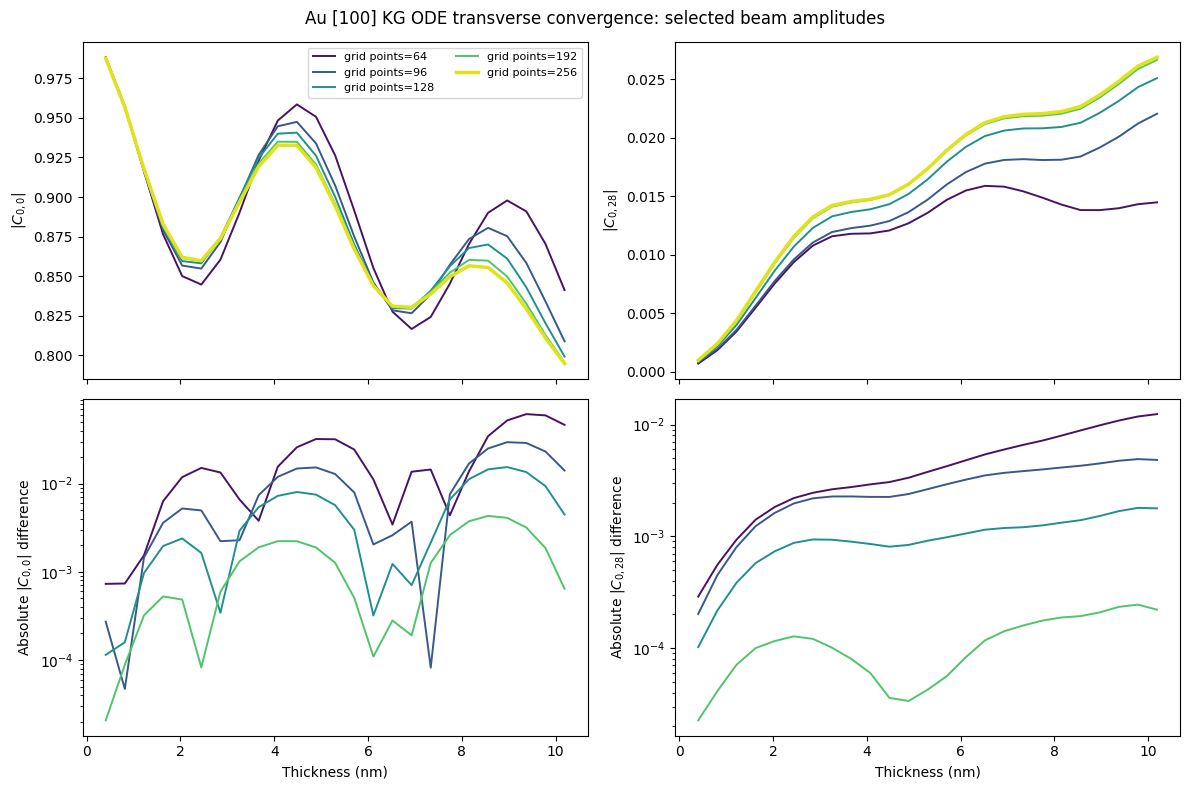

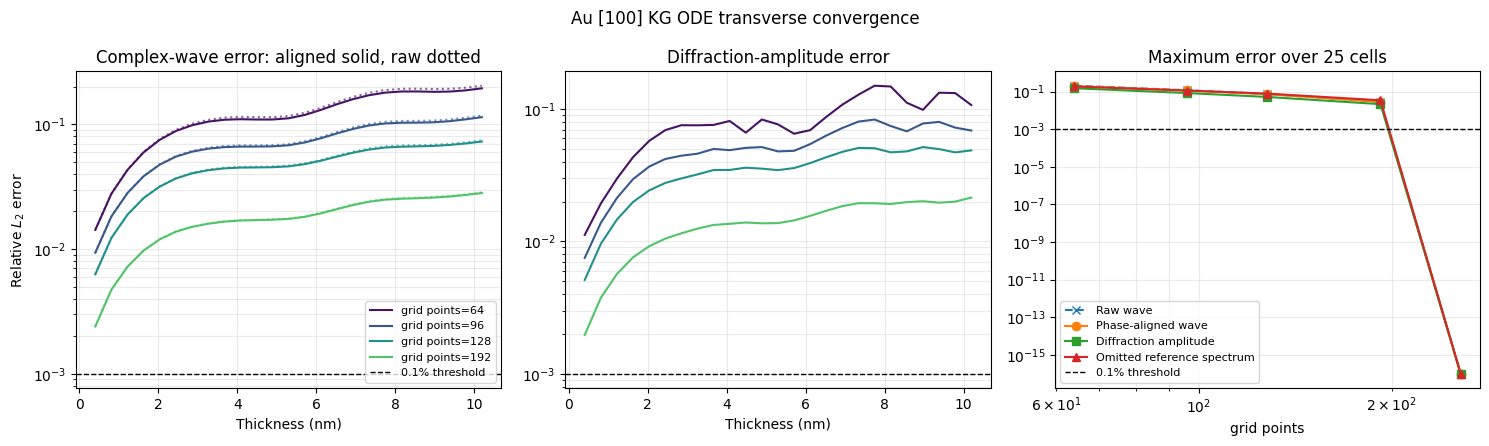

Lowest tested transverse resolution passing 0.1%: 256x256


In [6]:
def transverse_preflight(gpts_values=TRANSVERSE_PREFLIGHT_GPTS):
    k0 = 2 * np.pi / WAVELENGTH_A
    baseline_gpts = 128
    baseline_dtmax = None
    baseline_cell_s = None
    baseline_path = result_path("longitudinal", "candidate_g0128_z0256")
    if baseline_path.exists():
        with np.load(baseline_path, allow_pickle=False) as data:
            baseline_cell_s = float(np.median(data["runtime_s"]))

    rows = []
    for gpts in gpts_values:
        dx = AU_LATTICE_A / gpts
        frequencies = 2 * np.pi * np.fft.fftfreq(gpts, d=dx)
        kx, ky = np.meshgrid(frequencies, frequencies)
        k_perp = np.sqrt(kx**2 + ky**2)
        k_perp_max = float(np.max(k_perp))
        evanescent_fraction = float(np.mean(k_perp > k0))
        dtmax_vacuum = 3.5 / np.sqrt(k0**2 + k_perp_max**2)
        if gpts == baseline_gpts:
            baseline_dtmax = dtmax_vacuum

        stack_gib = 2 * TRANSVERSE_SLICES * gpts**2 * 8 / 2**30
        minimum_steps = max(
            N_CELLS * TRANSVERSE_SLICES,
            int(np.ceil(N_CELLS * CELL_THICKNESS_A / dtmax_vacuum)),
        )
        rows.append({
            "gpts": gpts,
            "dx": dx,
            "k_ratio": k_perp_max / k0,
            "evanescent": evanescent_fraction,
            "stack_gib": stack_gib,
            "minimum_steps": minimum_steps,
            "dtmax": dtmax_vacuum,
        })

    for row in rows:
        fft_ratio = (row["gpts"]**2 * np.log(row["gpts"]**2)) / (baseline_gpts**2 * np.log(baseline_gpts**2))
        row["relative_work"] = fft_ratio * baseline_dtmax / row["dtmax"]
        row["estimated_minutes"] = None if baseline_cell_s is None else baseline_cell_s * N_CELLS * row["relative_work"] / 60

    lines = [
        "| Grid | Pixel size (Å) | $k_{\\perp,\\max}/k_0$ | Vacuum-evanescent modes | Potential + $k_0^2n^2$ stack | Minimum internal steps | Estimated 25-cell runtime |",
        "|---:|---:|---:|---:|---:|---:|---:|",
    ]
    for row in rows:
        runtime = "n/a" if row["estimated_minutes"] is None else f'{row["estimated_minutes"]:.1f} min'
        lines.append(
            f'| {row["gpts"]}² | {row["dx"]:.5f} | {row["k_ratio"]:.2f} | '
            f'{100 * row["evanescent"]:.1f}% | {row["stack_gib"]:.2f} GiB | '
            f'{row["minimum_steps"]:,} | {runtime} |'
        )
    display(Markdown("\n".join(lines)))
    print("Runtime is an FFT-work estimate calibrated from the saved 128x128x256 run; compilation, checkpoint I/O, and potential construction are additional.")
    print("The memory column includes only the potential and refractive-index stacks, not adaptive-solver work arrays or JAX compilation caches.")


transverse_preflight()

transverse_reference_description = {
    "gpts": TRANSVERSE_REFERENCE_GPTS,
    "slices_per_cell": TRANSVERSE_SLICES,
}
transverse_reference = get_reference(
    "transverse",
    TRANSVERSE_REFERENCE_GPTS,
    TRANSVERSE_SLICES,
    RUN_TRANSVERSE,
)
transverse_results = {}
if transverse_reference is not None:
    for gpts in TRANSVERSE_GPTS:
        transverse_results[gpts] = get_candidate_metrics(
            "transverse",
            gpts,
            TRANSVERSE_SLICES,
            transverse_reference,
            transverse_reference_description,
            RUN_TRANSVERSE,
        )

plot_convergence_study(
    transverse_results,
    TRANSVERSE_REFERENCE_GPTS,
    "Au [100] KG ODE transverse convergence",
    "grid points",
)
lowest_transverse_resolution = lowest_passing_resolution(transverse_results)
if lowest_transverse_resolution is None:
    print("Lowest tested transverse resolution passing 0.1%: not available")
else:
    print(f"Lowest tested transverse resolution passing 0.1%: {lowest_transverse_resolution}x{lowest_transverse_resolution}")


## 3. Unit-cell chaining equivalence

This study compares the current production pattern—one ODE call per unit cell while carrying both $\psi$ and $\partial_z\psi$—against a single ODE call containing the explicitly concatenated potential.

The concatenated 25-cell call can compile slowly and use substantial memory because the current solver constructs the slice-dependent refractive-index stack inside the call. This calculation is therefore independently opt-in.

In [7]:
def relative_l2_single(candidate, reference):
    candidate = np.asarray(candidate).ravel()
    reference = np.asarray(reference).ravel()
    return float(np.linalg.norm(candidate - reference) / max(np.linalg.norm(reference), 1e-300))


def phase_aligned_l2_single(candidate, reference):
    candidate = np.asarray(candidate)
    reference = np.asarray(reference)
    overlap = np.vdot(candidate.ravel(), reference.ravel())
    aligned = candidate * np.exp(1j * np.angle(overlap))
    return relative_l2_single(aligned, reference)


def diffraction_amplitude(wave):
    return np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(wave))))


def chaining_config():
    return {
        **base_config("chaining", CHAIN_GPTS, CHAIN_SLICES, role="comparison"),
        "chain_lengths": list(CHAIN_LENGTHS),
    }


def run_or_load_chaining():
    config = chaining_config()
    path = result_path("chaining", f"g{CHAIN_GPTS:04d}_z{CHAIN_SLICES:04d}")
    loaded = load_result(path, config)
    if loaded is not None:
        print(f"Loaded chaining metrics -> {path.name}")
        return loaded
    if not RUN_CHAINING:
        print("Chaining result unavailable; enable RUN_CHAINING to compute it.")
        return None

    potential, probe, sampling, dz = build_au_cell(CHAIN_GPTS, CHAIN_SLICES)
    chained = propagate_repeated_cells(
        potential,
        probe,
        dz,
        sampling,
        max(CHAIN_LENGTHS),
        record_cells=CHAIN_LENGTHS,
        description="chained unit-cell calls",
    )

    raw_wave_error = []
    aligned_wave_error = []
    raw_phi_error = []
    amplitude_error = []
    concatenated_runtime_s = []

    for index, n_cells in enumerate(CHAIN_LENGTHS):
        print(f"Concatenated one-call propagation: {n_cells} cell(s)")
        concatenated_potential = jnp.tile(potential, (n_cells, 1, 1))
        start = perf_counter()
        wave, phi, diffraction, _ = simulate_kg_ode_full(
            concatenated_potential,
            probe,
            dz,
            ENERGY_EV,
            sampling,
            rtol=RTOL,
            atol=ATOL,
            save_wavefronts=False,
            solver_name=SOLVER_NAME,
        )
        jax.block_until_ready(phi)
        concatenated_runtime_s.append(perf_counter() - start)

        chained_wave = chained["waves"][index]
        chained_phi = chained["phis"][index]
        raw_wave_error.append(relative_l2_single(chained_wave, wave))
        aligned_wave_error.append(phase_aligned_l2_single(chained_wave, wave))
        raw_phi_error.append(relative_l2_single(chained_phi, phi))
        amplitude_error.append(relative_l2_single(diffraction_amplitude(chained_wave), np.sqrt(np.asarray(diffraction))))
        del concatenated_potential, wave, phi, diffraction
        release_memory()

    result = {
        "cells": np.asarray(CHAIN_LENGTHS, dtype=int),
        "raw_wave_rel_l2": np.asarray(raw_wave_error),
        "aligned_wave_rel_l2": np.asarray(aligned_wave_error),
        "raw_phi_rel_l2": np.asarray(raw_phi_error),
        "diffraction_amplitude_rel_l2": np.asarray(amplitude_error),
        "chained_runtime_s": chained["runtime_s"],
        "concatenated_runtime_s": np.asarray(concatenated_runtime_s),
        "sampling_A": np.asarray(sampling),
        "slice_thickness_A": np.asarray(dz),
    }
    save_result(path, config, **result)
    del potential, probe, chained
    release_memory()
    return result


chaining_result = run_or_load_chaining()
if chaining_result is not None:
    thickness_nm = chaining_result["cells"] * CELL_THICKNESS_A / 10.0
    fig, axis = plt.subplots(figsize=(8, 5))
    axis.semilogy(thickness_nm, np.maximum(chaining_result["raw_wave_rel_l2"], 1e-16), "o-", label=r"Raw $\psi$")
    axis.semilogy(thickness_nm, np.maximum(chaining_result["raw_phi_rel_l2"], 1e-16), "s-", label=r"Raw $\partial_z\psi$")
    axis.semilogy(thickness_nm, np.maximum(chaining_result["diffraction_amplitude_rel_l2"], 1e-16), "^-", label="Diffraction amplitude")
    axis.axhline(CONVERGENCE_THRESHOLD, color="black", ls="--", label="0.1% threshold")
    axis.set_xlabel("Thickness (nm)")
    axis.set_ylabel("Chained vs concatenated relative $L_2$ error")
    axis.set_title("Au [100] KG ODE unit-cell chaining equivalence")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend()
    plt.show()

Chaining result unavailable; enable RUN_CHAINING to compute it.


## Final acceptance summary

For longitudinal and transverse convergence, the current production resolution passes only if both the maximum phase-aligned complex-wave error and maximum diffraction-amplitude error remain below 0.1% over all 25 cell boundaries.

For unit-cell chaining, the raw wave, raw derivative, and diffraction-amplitude differences must all remain below 0.1%. Missing studies are reported explicitly rather than treated as failures.

In [8]:
def study_acceptance(data, include_phi=False):
    if data is None:
        return None, None, "Not run"
    metrics = {
        "aligned wave": float(np.max(data["aligned_wave_rel_l2"])),
        "diffraction amplitude": float(np.max(data["diffraction_amplitude_rel_l2"])),
    }
    if include_phi:
        metrics = {
            "raw wave": float(np.max(data["raw_wave_rel_l2"])),
            "raw phi": float(np.max(data["raw_phi_rel_l2"])),
            "diffraction amplitude": float(np.max(data["diffraction_amplitude_rel_l2"])),
        }
    maximum = max(metrics.values())
    detail = ", ".join(f"{name}={value:.3e}" for name, value in metrics.items())
    return maximum, maximum < CONVERGENCE_THRESHOLD, detail


longitudinal_current = longitudinal_results.get(128)
transverse_current = transverse_results.get(128)
summary_rows = [
    ("Longitudinal sampling: 128 vs 512 slices/cell", *study_acceptance(longitudinal_current)),
    (f"Transverse sampling: 128 vs {TRANSVERSE_REFERENCE_GPTS} grid", *study_acceptance(transverse_current)),
    ("Unit-cell chaining: chained vs concatenated", *study_acceptance(chaining_result, include_phi=True)),
]

lines = [
    "| Verification | Maximum relevant error | Status | Details |",
    "|---|---:|:---:|---|",
]
for name, maximum, passed, detail in summary_rows:
    maximum_text = "—" if maximum is None else f"{maximum:.3e}"
    status = "NOT RUN" if passed is None else ("PASS" if passed else "FAIL")
    lines.append(f"| {name} | {maximum_text} | **{status}** | {detail} |")

display(Markdown("\n".join(lines)))

lowest_longitudinal = lowest_passing_resolution(longitudinal_results)
lowest_transverse = lowest_passing_resolution(transverse_results)
print(f"Lowest tested longitudinal resolution passing 0.1%: {lowest_longitudinal}")
print(f"Lowest tested transverse resolution passing 0.1%: {lowest_transverse}")

completed = [passed for _, _, passed, _ in summary_rows if passed is not None]
if len(completed) == 3 and all(completed):
    display(Markdown("**Conclusion:** the current $128\\times128\\times128$ Au reference configuration passes all requested checks over 25 unit cells."))
elif completed:
    display(Markdown("**Conclusion:** inspect the failed or missing checks before treating the current Au ODE reference as converged."))

| Verification | Maximum relevant error | Status | Details |
|---|---:|:---:|---|
| Longitudinal sampling: 128 vs 512 slices/cell | — | **NOT RUN** | Not run |
| Transverse sampling: 128 vs 256 grid | 7.275e-02 | **FAIL** | aligned wave=7.275e-02, diffraction amplitude=5.161e-02 |
| Unit-cell chaining: chained vs concatenated | — | **NOT RUN** | Not run |

Lowest tested longitudinal resolution passing 0.1%: None
Lowest tested transverse resolution passing 0.1%: 256


**Conclusion:** inspect the failed or missing checks before treating the current Au ODE reference as converged.

## Interpretation notes

- Passing the longitudinal study supports the chosen piecewise-constant potential discretization over the tested 10 nm thickness.
- Passing the default transverse study supports the retained lateral Fourier bandwidth relative to the practical $256\times256$ reference. Inspect the omitted-spectrum curve, and use the optional $384\times384$ confirmation before making a stronger claim if the result is near the threshold.
- Passing the chaining study confirms that restarting the adaptive integrator at unit-cell boundaries does not materially alter the result when both $\psi$ and $\partial_z\psi$ are carried forward.
- These tests validate numerical convergence of the entrance-initialized second-order KG ODE calculation. They do not convert it into a two-sided scattering boundary-value solution or quantify the physical backscattering omitted by the forward-scattering boundary assumption.
